In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import pandas as pd
import seaborn as sns
from scipy.stats import qmc
from ipywidgets import IntProgress
import math as math

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

from ewatercycle_discharge import DischargeLocal

shape_file_area = 7.629080e+03 # in km^2

In [2]:
basin_name = "boven_suriname"

historical_start_date = "2019-01-01"
historical_end_date = "2024-12-31"
future_start_data = "2027-01-01"
future_end_data = "2099-12-31"

shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "boven_suriname.shp"

forcing_route_CMIP = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "CMIP"

forcing_route = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "ERA5_SUR_2019_2024"/ "work" / "diagnostic" / "script" 

Eigen_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "discharge_bmi"
# model_path_HBV = Path.home() / "tmp" / "HBV_model" / "CMIP"
# model_path_HBV.mkdir(exist_ok=True)

# gdf = gpd.read_file("estreams_cb_FR003882.shp")
# gdf = gdf.to_crs(epsg=2154)
# gdf["area_km2"] = gdf.geometry.area / 1e6  
# basin_area = gdf["area_km2"].sum()

In [3]:
# # Option one: Generate CMIP data
# cmip_dataset =  {
#    'project': 'CMIP6',
#    'activity': 'ScenarioMIP',
#    'exp': 'ssp245',              # veranderen per generatie CMIP data
#    'mip': 'day',
#    'dataset': 'MPI-ESM1-2-HR',
#    'ensemble': 'r1i1p1f1',
#    'institute': 'DKRZ',
#    'grid': 'gn'
# }

# cmip_historical =  {
#    'project': 'CMIP6',
#    'exp': 'historical',
#    'dataset': 'MPI-ESM1-2-HR',
#    "ensemble": 'r1i1p1f1',
#    'grid': 'gn'
# }

# ssp126_dir = forcing_route_CMIP / "SSP126_26-99"
# ssp245_dir = forcing_route_CMIP / "SSP245_26-99"
# ssp585_dir = forcing_route_CMIP / "SSP585_26-99"
# historical = forcing_route_CMIP / "historical"

# CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#    dataset=cmip_dataset,        # veranderen per generatie CMIP data
#    start_time=historical_start_date+"T00:00:00Z",
#    end_time=historical_end_date+"T00:00:00Z",
#    shape=shapefile,
#    directory=historical,        # veranderen per generatie CMIP data
# )

In [4]:
# Option two: load generated data
# Load historical data
historic_location = forcing_route_CMIP / "historical" / "work" / "diagnostic" / "script" 
HIST = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historic_location)

# Load SSP126 data
ssp126_location = forcing_route_CMIP / "SSP126_26-99" / "work" / "diagnostic" / "script" 
SSP126 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp126_location)

# Load SSP245 data
ssp245_location = forcing_route_CMIP / "SSP245_26-99" / "work" / "diagnostic" / "script" 
SSP245 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp245_location)

# Load SSP585 data
ssp585_location = forcing_route_CMIP / "SSP585_26-99" / "work" / "diagnostic" / "script" 
SSP585 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp585_location)

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_route)
evap = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag

In [5]:
def level(Qin, Qout, ERA5_forcing, A, L0):
    # Qin is array met discharge van rivier in meer, gebaseerd op E en P en dagelijks [m^3/s]
    # Qout is een standaard baseflow uit het meer [m^3/s]
    # E is verdampingsdata van ERA5, dagelijks [mm/s]
    # A is oppervlakte meer [km^2]
    # L0 is een gegeven begin hoogte [m]
    # L0 moet handmatig worden ingevoerd omdat in de toekomst niet zeker is hoe hoog het meer gaat staan op het beginpunt van de forcing data
    
    dt = 3600*24
    E = ERA5_forcing.to_xarray()["evspsblpot"] /1000 #* dt
    L = np.zeros(len(Qin))
    L[0] = L0
    A = A * 10**6
    
    for i in range(len(Qin)-1):
        dL = ((Qin.iloc[i] - Qout) / A) - E[i]
        L[i+1] = L[i] + dL*dt 
        if L[i+1] > 48.5:
            L[i+1] = 48.5
    return L

In [6]:
model = DischargeLocal(forcing = ERA5_forcing)
params = [1.30978424, 0.39171679, 1.05045276]
config_file, _ = model.setup(parameters=params, cfg_dir=Eigen_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
# print(model_output_mmday.max())
model_output_m3s_test = model_output_mmday * shape_file_area * 1000 / 86400

In [7]:
print(HIST)
print(SSP126)
print(SSP245)
print(SSP585)

start_time='2019-01-01T00:00:00Z' end_time='2024-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_pr_gn_2019-2024.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_tas_gn_2019-2024.nc', 'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_rsds_gn_2019-2024.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}
start_time='2027-01-01T00:00:00Z' end_time='2099-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/SSP126_26-99/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/SSP126_26-99/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_pr_gn_2027-2099.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_tas_gn_2027-2099.nc

In [8]:
forcing_list = [HIST, SSP126, SSP245, SSP585] 
output = []
years = []
params = [1.30978424, 0.39171679, 1.05045276]

for forcings in forcing_list:
    model = DischargeLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=params, 
        cfg_dir = Eigen_model,
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output.append(Q_m)
    years.append(time)
    
    del Q_m, time
    model.finalize()

In [9]:
historical_output = pd.Series(data=output[0], name="Historical", index=years[0])["2019-01-01":]
SSP126_output = pd.Series(data=output[1], name="SSP126", index=years[1])["2027-01-01":]
SSP245_output = pd.Series(data=output[2], name="SSP245", index=years[2])["2027-01-01":]
SSP585_output = pd.Series(data=output[3], name="SSP585", index=years[3])["2027-01-01":]

# Convert mm/d to m3/s
factor = shape_file_area / 86.4
historical_output *= factor
SSP126_output *= factor
SSP245_output *= factor
SSP585_output *= factor

In [10]:
parameter_test = [1.30978424, 0.39171679, 1.05045276]
model = DischargeLocal(forcing = ERA5_forcing)
config_file, _ = model.setup(parameters=parameter_test, cfg_dir=Eigen_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_pr_gn_2019-2024.nc
/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/Derived_Makkink_evspsblpot.nc


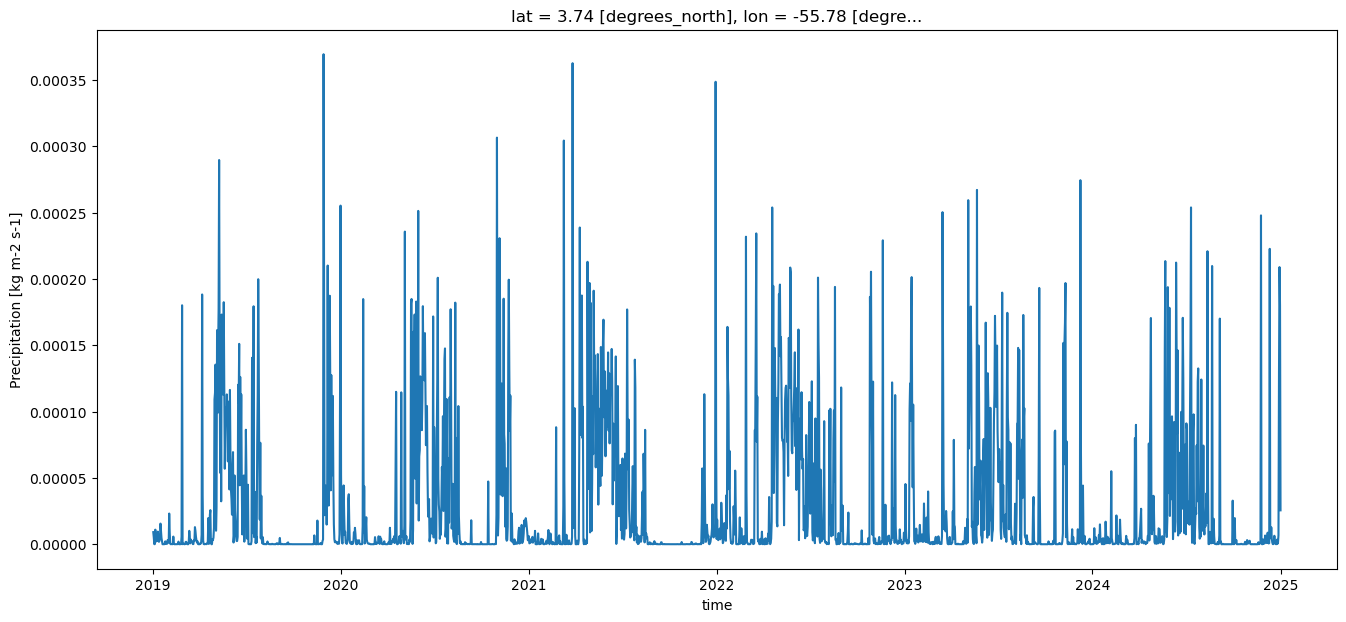

In [11]:
plt.figure(figsize=(16, 7))
print(HIST["pr"])
print(HIST["evspsblpot"])
# plt.plot(HIST.index, HIST["pr"])
# print(historical_output)
evap_hist = HIST.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec_hist = HIST.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
# print(evap_hist)
# print(prec_hist)
prec_hist.plot()

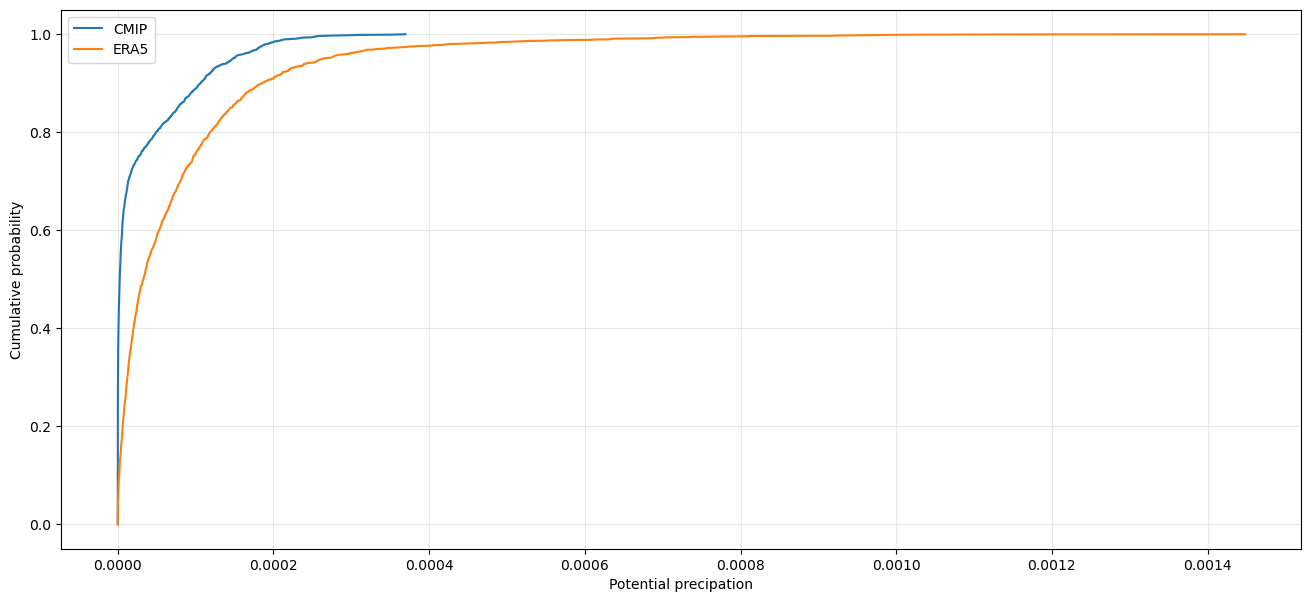

In [12]:
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]      # remove NaNs
    x = np.sort(x)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_cmip, y_cmip = ecdf(prec_hist)
x_era5, y_era5 = ecdf(prec)

plt.figure(figsize=(16, 7))

plt.plot(x_cmip, y_cmip, label='CMIP')
plt.plot(x_era5, y_era5, label='ERA5')

plt.xlabel('Potential precipation')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [13]:
# Evaporation quantile mapping

# evap_hist_corr = evap_cmip * era5_e.mean() / cmip_hist_e.mean()
evap_hist_corr = evap_hist * evap.mean() / evap_hist.mean()

In [14]:
# test nummer 2

In [15]:
prec = prec.compute()
evap = evap.compute()

prec_hist = prec_hist.compute()
evap_hist = evap_hist.compute()

In [16]:
thr = 1e-7
era_wet = prec.values[prec.values > thr]

hist_wet = prec_hist.values[
    prec_hist.values > thr
]

In [17]:
q = np.linspace(0,1,1000)

era_q_pr = np.quantile(era_wet, q)

hist_q_pr = np.quantile(hist_wet, q)

era_q_evap = np.quantile(evap.values, q)

hist_q_evap = np.quantile(evap_hist.values,q)

In [18]:
pr = prec_hist.values.copy()
wet_frac_era = (prec.values > thr).mean()
# find CMIP threshold that yields same wet-day fraction
thr_cmip = np.quantile( prec_hist.values, 1 - wet_frac_era)
mask = prec_hist.values > thr_cmip

pr_corr = np.zeros_like(pr)

pr_corr[mask] = np.interp(pr[mask], hist_q_pr, era_q_pr, left=era_q_pr[0], right=era_q_pr[-1])

prec_hist_corr = xr.DataArray(pr_corr, coords=prec_hist.coords, dims=prec_hist.dims, attrs=prec_hist.attrs,)

scale = (prec.mean()/prec_hist_corr.mean())**0.5

prec_hist_corr *= scale

In [19]:
ev = evap_hist.values.copy()

ev_corr = np.interp(ev, hist_q_evap, era_q_evap, left=era_q_evap[0], right=era_q_evap[-1])

evap_hist_corr = xr.DataArray(ev_corr, coords=evap_hist.coords, dims=evap_hist.dims, attrs=evap_hist.attrs,)

In [20]:
# ssp126_ds = SSP126.to_xarray()
# pr126 = ssp126_ds["pr"].compute()
# evap126 = ssp126_ds["evspsblpot"].compute()
# pr126_np = pr126.values.copy()
# pr126_corr = np.zeros_like(pr126_np)
# mask = pr126_np > thr
# pr126_corr[mask] = np.interp(pr126_np[mask], hist_q_pr,era_q_pr, left=era_q_pr[0], right = era_q_pr[-1])
# evap126_corr = np.interp(evap126.values, hist_q_evap, era_q_evap, left=era_q_evap[0], right=era_q_evap[-1])

# ssp245_ds = SSP245.to_xarray()
# pr245 = ssp245_ds["pr"].compute()
# evap245 = ssp245_ds["evspsblpot"].compute()
# pr245_np = pr245.values.copy()
# pr245_corr = np.zeros_like(pr245_np)
# mask = pr245_np > thr
# pr245_corr[mask] = np.interp(pr245_np[mask], hist_q_pr,era_q_pr, left=era_q_pr[0], right = era_q_pr[-1])
# evap245_corr = np.interp(evap245.values, hist_q_evap, era_q_evap, left=era_q_evap[0], right=era_q_evap[-1])

# ssp585_ds = SSP585.to_xarray()
# pr585 = ssp585_ds["pr"].compute()
# evap585 = ssp585_ds["evspsblpot"].compute()
# pr585_np = pr585.values.copy()
# pr585_corr = np.zeros_like(pr585_np)
# mask = pr585_np > thr
# pr585_corr[mask] = np.interp(pr585_np[mask], hist_q_pr,era_q_pr, left=era_q_pr[0], right = era_q_pr[-1])
# evap585_corr = np.interp(evap585.values, hist_q_evap, era_q_evap, left=era_q_evap[0], right=era_q_evap[-1])

In [21]:
# chatgpt versie van quantile mapping van historical hetzelfde toepassen op de ssp 
ssp126_ds = SSP126.to_xarray()

pr126 = ssp126_ds["pr"].compute()
evap126 = ssp126_ds["evspsblpot"].compute()

pr126_np = pr126.values.copy()
pr126_corr = np.zeros_like(pr126_np)

# use historical wet-day threshold
mask = pr126_np > thr_cmip

pr126_corr[mask] = np.interp(
    pr126_np[mask],
    hist_q_pr,
    era_q_pr,
    left=era_q_pr[0],
    right=era_q_pr[-1]
)

pr126_corr = xr.DataArray(
    pr126_corr,
    coords=pr126.coords,
    dims=pr126.dims,
    attrs=pr126.attrs,
)

# apply same scaling as historical
pr126_corr *= scale

evap126_corr = xr.DataArray(
    np.interp(
        evap126.values,
        hist_q_evap,
        era_q_evap,
        left=era_q_evap[0],
        right=era_q_evap[-1]
    ),
    coords=evap126.coords,
    dims=evap126.dims,
    attrs=evap126.attrs,
)

ssp245_ds = SSP245.to_xarray()

pr245 = ssp245_ds["pr"].compute()
evap245 = ssp245_ds["evspsblpot"].compute()

pr245_np = pr245.values.copy()
pr245_corr = np.zeros_like(pr245_np)

mask = pr245_np > thr_cmip

pr245_corr[mask] = np.interp(
    pr245_np[mask],
    hist_q_pr,
    era_q_pr,
    left=era_q_pr[0],
    right=era_q_pr[-1]
)

pr245_corr = xr.DataArray(
    pr245_corr,
    coords=pr245.coords,
    dims=pr245.dims,
    attrs=pr245.attrs,
)

pr245_corr *= scale

evap245_corr = xr.DataArray(
    np.interp(
        evap245.values,
        hist_q_evap,
        era_q_evap,
        left=era_q_evap[0],
        right=era_q_evap[-1]
    ),
    coords=evap245.coords,
    dims=evap245.dims,
    attrs=evap245.attrs,
)

ssp585_ds = SSP585.to_xarray()

pr585 = ssp585_ds["pr"].compute()
evap585 = ssp585_ds["evspsblpot"].compute()

pr585_np = pr585.values.copy()
pr585_corr = np.zeros_like(pr585_np)

mask = pr585_np > thr_cmip

pr585_corr[mask] = np.interp(
    pr585_np[mask],
    hist_q_pr,
    era_q_pr,
    left=era_q_pr[0],
    right=era_q_pr[-1]
)

pr585_corr = xr.DataArray(
    pr585_corr,
    coords=pr585.coords,
    dims=pr585.dims,
    attrs=pr585.attrs,
)

pr585_corr *= scale

evap585_corr = xr.DataArray(
    np.interp(
        evap585.values,
        hist_q_evap,
        era_q_evap,
        left=era_q_evap[0],
        right=era_q_evap[-1]
    ),
    coords=evap585.coords,
    dims=evap585.dims,
    attrs=evap585.attrs,
)

In [22]:
SSP126_corr_ds = SSP126.to_xarray().copy()
SSP126_corr_ds["pr"] = xr.DataArray( pr126_corr, coords=pr126.coords, dims=pr126.dims, attrs=pr126.attrs, )
SSP126_corr_ds["evspsblpot"] = xr.DataArray( evap126_corr, coords=evap126.coords, dims=evap126.dims, attrs=evap126.attrs,)

SSP245_corr_ds = SSP245.to_xarray().copy()
SSP245_corr_ds["pr"] = xr.DataArray( pr245_corr, coords=pr245.coords, dims=pr245.dims, attrs=pr245.attrs, )
SSP245_corr_ds["evspsblpot"] = xr.DataArray( evap245_corr, coords=evap245.coords, dims=evap245.dims, attrs=evap245.attrs,)

SSP585_corr_ds = SSP585.to_xarray().copy()
SSP585_corr_ds["pr"] = xr.DataArray( pr585_corr, coords=pr585.coords, dims=pr585.dims, attrs=pr585.attrs, )
SSP585_corr_ds["evspsblpot"] = xr.DataArray( evap585_corr, coords=evap585.coords, dims=evap585.dims, attrs=evap585.attrs,)

HIST_corr_ds = HIST.to_xarray().copy()
HIST_corr_ds["pr"] = xr.DataArray( prec_hist_corr, coords=prec_hist.coords, dims=prec_hist.dims, attrs=prec_hist.attrs, )
HIST_corr_ds["evspsblpot"] = xr.DataArray( evap_hist_corr, coords=evap_hist.coords, dims=evap_hist.dims, attrs=evap_hist.attrs,)

In [23]:
HIST_corr_ds.to_netcdf(
    historic_location / "forcing_biascorr.nc"
)
SSP126_corr_ds.to_netcdf(
    ssp126_location / "forcing_biascorr.nc"
)
SSP245_corr_ds.to_netcdf(
    ssp245_location / "forcing_biascorr.nc"
)
SSP585_corr_ds.to_netcdf(
    ssp585_location / "forcing_biascorr.nc"
)

HIST_corr = HIST.model_copy(deep=True)

SSP126_corr = SSP126.model_copy(deep=True)

SSP245_corr = SSP245.model_copy(deep=True)

SSP585_corr = SSP585.model_copy(deep=True)

In [24]:
print(HIST_corr.filenames)

{'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_pr_gn_2019-2024.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_tas_gn_2019-2024.nc', 'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_rsds_gn_2019-2024.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}


In [25]:
HIST_corr.filenames["pr"] = "forcing_biascorr.nc"
HIST_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

SSP126_corr.filenames["pr"] = "forcing_biascorr.nc"
SSP126_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

SSP245_corr.filenames["pr"] = "forcing_biascorr.nc"
SSP245_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

SSP585_corr.filenames["pr"] = "forcing_biascorr.nc"
SSP585_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

In [26]:
# print(HIST_corr)
# print(HIST_corr.filenames)
test = HIST_corr.to_xarray()

# print(test)
# print(test["pr"])

In [27]:
forcing_list = [HIST_corr, SSP126_corr, SSP245_corr, SSP585_corr] 
output_corr = []
years_corr = []
params = [1.30978424, 0.39171679, 1.05045276]

for forcings in forcing_list:
    model = DischargeLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=params, 
        cfg_dir = Eigen_model,
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output_corr.append(Q_m)
    years_corr.append(time)
    
    del Q_m, time
    model.finalize()

In [28]:
historical_output = pd.Series(data=output_corr[0], name="Historical", index=years[0])["2019-01-01":]
SSP126_output = pd.Series(data=output_corr[1], name="SSP126", index=years[1])["2027-01-01":]
SSP245_output = pd.Series(data=output_corr[2], name="SSP245", index=years[2])["2027-01-01":]
SSP585_output = pd.Series(data=output_corr[3], name="SSP585", index=years[3])["2027-01-01":]

# Convert mm/d to m3/s
factor = shape_file_area / 86.4
historical_output *= factor
SSP126_output *= factor
SSP245_output *= factor
SSP585_output *= factor

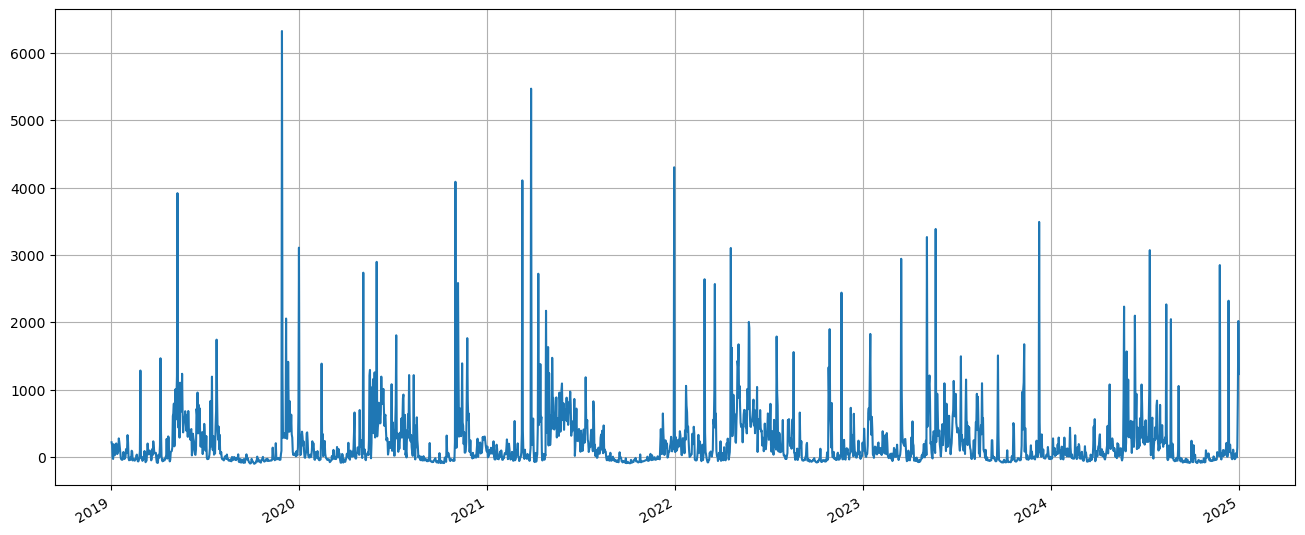

In [29]:
plt.figure(figsize=(16, 7))
historical_output.plot()
plt.grid();

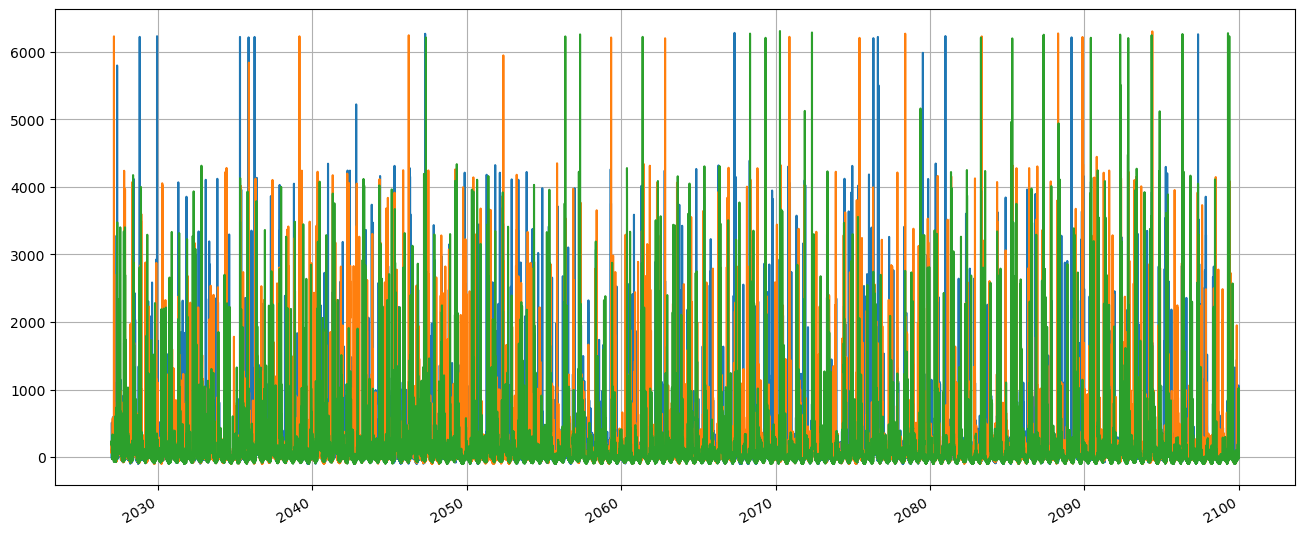

In [30]:
plt.figure(figsize=(16, 7))
SSP126_output.plot()
SSP245_output.plot()
SSP585_output.plot()
plt.grid();

In [31]:
print(SSP126_output.index)

DatetimeIndex(['2027-01-02 12:00:00', '2027-01-03 12:00:00',
               '2027-01-04 12:00:00', '2027-01-05 12:00:00',
               '2027-01-06 12:00:00', '2027-01-07 12:00:00',
               '2027-01-08 12:00:00', '2027-01-09 12:00:00',
               '2027-01-10 12:00:00', '2027-01-11 12:00:00',
               ...
               '2099-12-22 12:00:00', '2099-12-23 12:00:00',
               '2099-12-24 12:00:00', '2099-12-25 12:00:00',
               '2099-12-26 12:00:00', '2099-12-27 12:00:00',
               '2099-12-28 12:00:00', '2099-12-29 12:00:00',
               '2099-12-30 12:00:00', '2099-12-31 12:00:00'],
              dtype='datetime64[ns]', length=26662, freq=None)


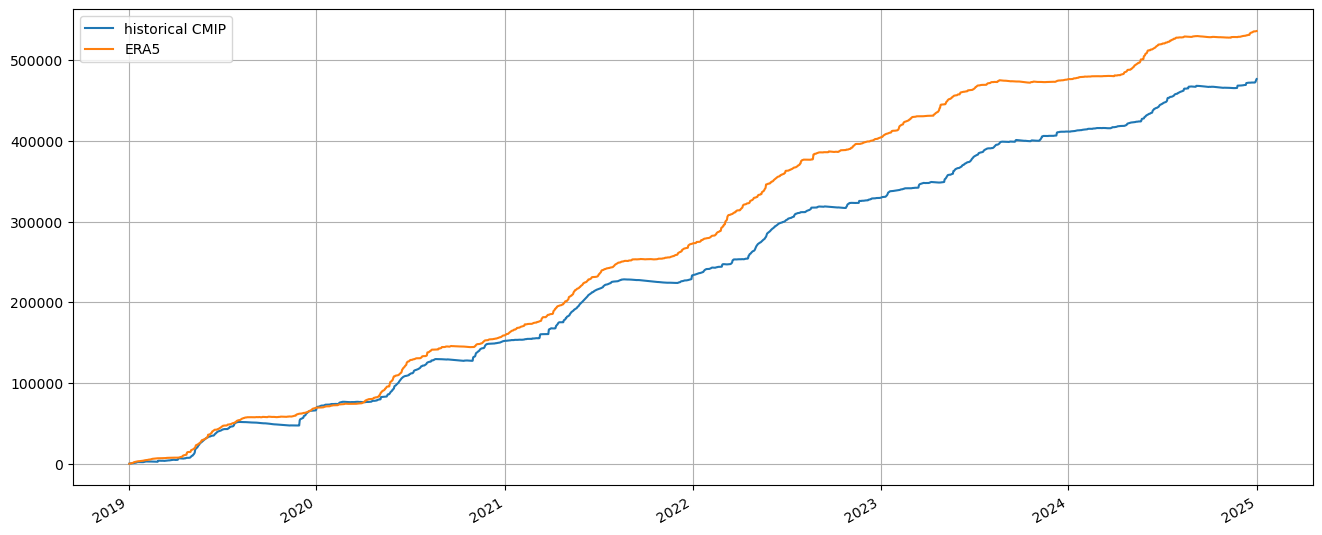

In [32]:
plt.figure(figsize=(16, 7))

historical_output_sum = historical_output.cumsum()
SSP126_output_sum = SSP126_output.cumsum()
SSP245_output_sum = SSP245_output.cumsum()
SSP585_output_sum = SSP585_output.cumsum()
model_output_m3s_test_sum = model_output_m3s_test.cumsum()

historical_output_sum.plot(label = "historical CMIP")
# SSP126_output_sum.plot(label = "SSP126")
# SSP245_output_sum.plot(label = "SSP245")
# SSP585_output_sum.plot(label = "SSP585")
model_output_m3s_test_sum.plot(label = "ERA5")

plt.legend()
plt.grid();

In [33]:
print((prec.values > thr).mean())
print((prec_hist.values > thr).mean())
print((prec_hist_corr.values > thr).mean())

0.9621350364963503
0.7559306569343066
0.9621350364963503


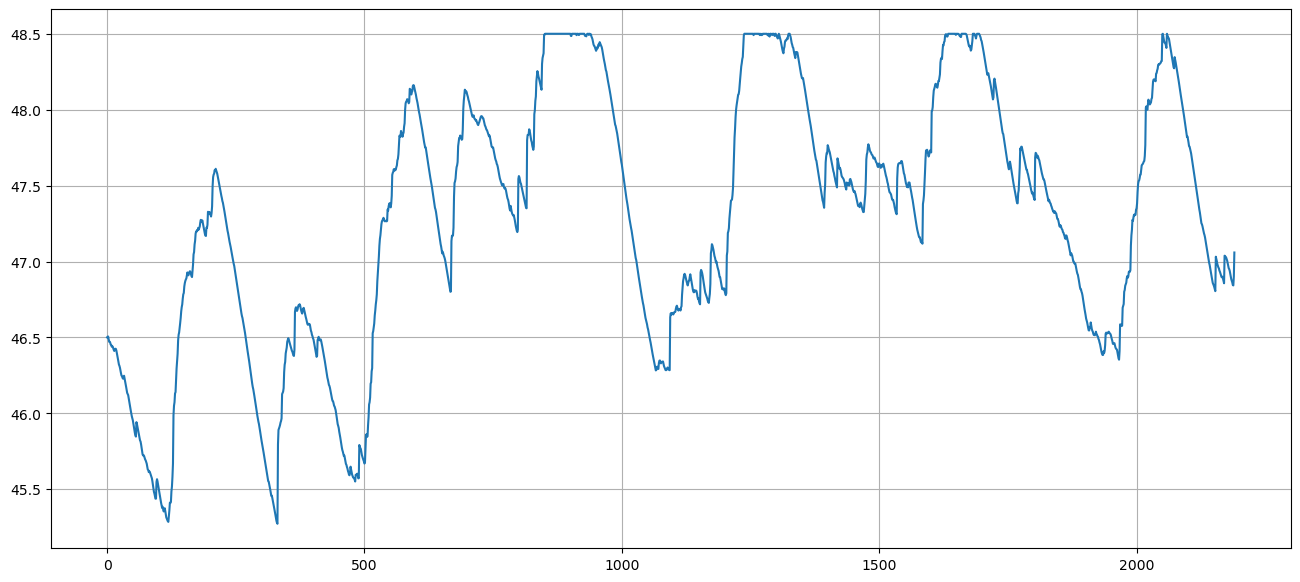

In [34]:
plt.figure(figsize=(16, 7))
Q_out = 144.7
A = 1020
L0 = 46.5
historical_level = level(historical_output, Q_out, HIST_corr, A, L0)
plt.plot(historical_level)
plt.grid();

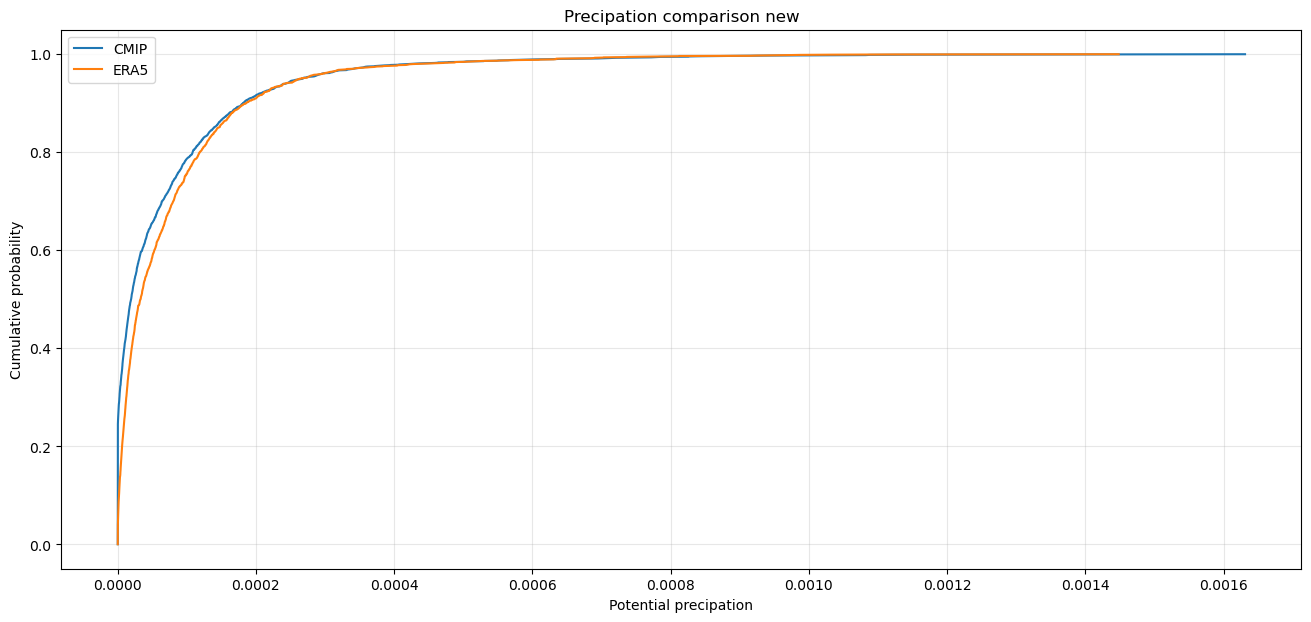

In [35]:
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]      # remove NaNs
    x = np.sort(x)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

# x_cmip, y_cmip = ecdf(historical_output)
x_cmip, y_cmip = ecdf(test["pr"])
x_era5, y_era5 = ecdf(prec)
# x_era5 *= 3600*24

plt.figure(figsize=(16, 7))

plt.plot(x_cmip, y_cmip, label='CMIP')
plt.plot(x_era5, y_era5, label='ERA5')

plt.xlabel('Potential precipation')
plt.ylabel('Cumulative probability')
plt.title("Precipation comparison new")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
print("ERA5:", float(prec.mean()*86400))
print("CMIP:", float(prec_hist.mean()*86400))
print("Corrected:", float(prec_hist_corr.mean()*86400))

ERA5: 6.509638926945627
CMIP: 2.429778833175078
Corrected: 5.7798274559900165


In [37]:
SSP126_level = level(SSP126_output, Q_out, SSP126_corr, A, L0)
SSP245_level = level(SSP245_output, Q_out, SSP245_corr, A, L0)
SSP585_level = level(SSP585_output, Q_out, SSP585_corr, A, L0)

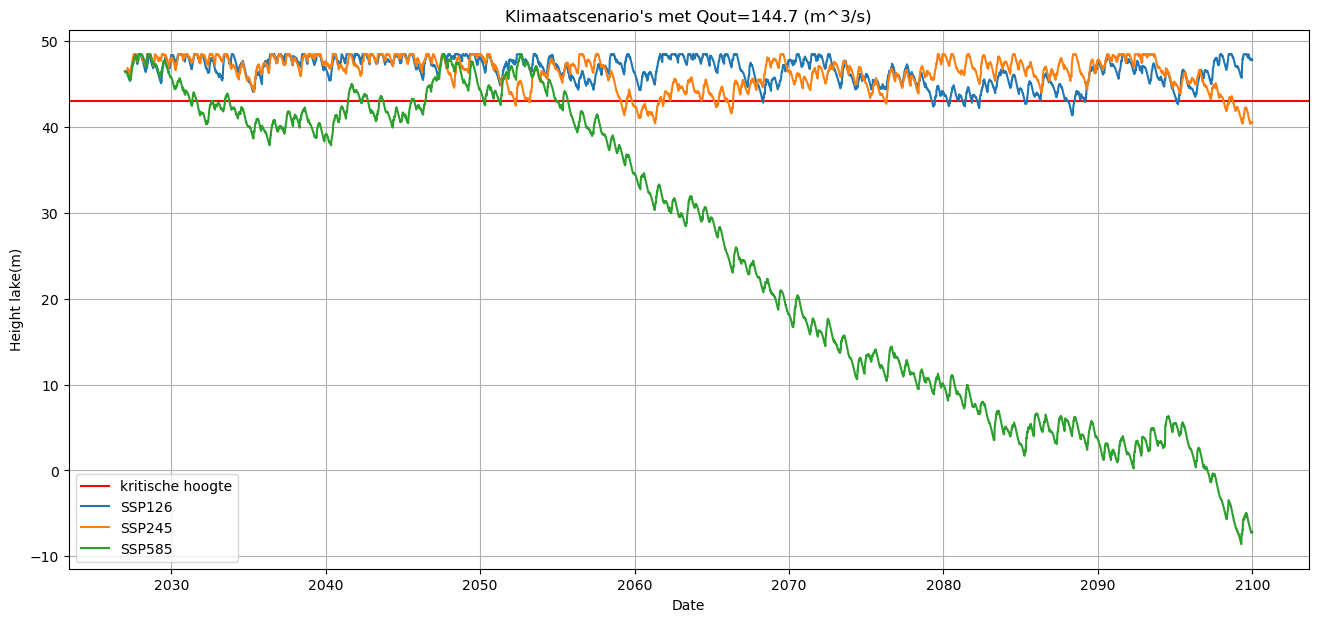

In [38]:
plt.figure(figsize=(16, 7))
plt.axhline(43, color = "r", label = "kritische hoogte")
plt.plot(SSP126_output.index, SSP126_level, label = "SSP126")
plt.plot(SSP245_output.index, SSP245_level, label = "SSP245")
plt.plot(SSP585_output.index, SSP585_level, label = "SSP585")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Height lake(m)")
plt.title("Klimaatscenario's met Qout=144.7 (m^3/s)")
plt.grid()

In [41]:
print(SSP126_level)

[46.5        46.4837217  46.47497381 ... 47.8958734  47.88907508
 47.87293714]


In [61]:
def droogte(level, L_crit, start_date):

    # Create daily dates
    dates = pd.date_range(
        start=start_date,
        periods=len(level),
        freq="D"
    )

    level = pd.Series(level, index=dates)

    # Make Series
    level = pd.Series(level, index=dates)

    # Determine drought days
    drought = level < L_crit

    # Find consecutive drought periods
    groups = (drought != drought.shift()).cumsum()

    events = []

    for _, group in drought.groupby(groups):

        if group.iloc[0]:  # only drought groups

            start = group.index[0]
            end = group.index[-1]

            duration = (end - start).days + 1

            events.append({
                "start": start,
                "end": end,
                "duration_days": duration
            })

    events = pd.DataFrame(events)

    return drought, events

In [62]:
drought_hist, events_hist = droogte(historical_level, 43, "2019-01-01")
drought_ssp126, events_ssp126 = droogte(SSP126_level, 43, "2027-01-01")
drought_ssp245, events_ssp245 = droogte(SSP245_level, 43, "2027-01-01")
drought_ssp585, events_ssp585 = droogte(SSP585_level, 43, "2027-01-01")

print(drought_hist, events_hist)
print(drought_ssp126, events_ssp126)
print(drought_ssp245, events_ssp245)
print(drought_ssp585, events_ssp585)

2019-01-01    False
2019-01-02    False
2019-01-03    False
2019-01-04    False
2019-01-05    False
              ...  
2024-12-26    False
2024-12-27    False
2024-12-28    False
2024-12-29    False
2024-12-30    False
Freq: D, Length: 2191, dtype: bool Empty DataFrame
Columns: []
Index: []
2027-01-01    False
2027-01-02    False
2027-01-03    False
2027-01-04    False
2027-01-05    False
              ...  
2099-12-26    False
2099-12-27    False
2099-12-28    False
2099-12-29    False
2099-12-30    False
Freq: D, Length: 26662, dtype: bool         start        end  duration_days
0  2068-04-17 2068-04-26             10
1  2079-04-03 2079-06-12             71
2  2080-04-03 2080-06-02             61
3  2081-04-01 2081-06-01             62
4  2081-10-28 2081-11-07             11
5  2082-03-14 2082-05-01             49
6  2085-04-06 2085-05-23             48
7  2088-01-29 2088-01-29              1
8  2088-01-31 2088-06-25            147
9  2089-02-24 2089-02-28              5
10 2095-02-

In [67]:
def droogte(level, L_crit, start_date):

    # Create daily dates
    dates = pd.date_range(
        start=start_date,
        periods=len(level),
        freq="D"
    )

    # Make Series
    level = pd.Series(level, index=dates)

    # Determine drought days
    drought = level < L_crit

    # Daily deficit (0 if level >= L_crit)
    deficit = (L_crit - level).clip(lower=0)

    # Find consecutive drought periods
    groups = (drought != drought.shift()).cumsum()

    events = []

    for _, group in drought.groupby(groups):

        if group.iloc[0]:  # only drought groups

            start = group.index[0]
            end = group.index[-1]

            duration = (end - start).days + 1

            # Deficit during this event
            event_deficit = deficit.loc[start:end]

            max_deficit = event_deficit.max()
            cum_deficit = event_deficit.sum()
            mean_deficit = event_deficit.mean()

            events.append({
                "start": start,
                "end": end,
                "duration_days": duration,
                "max_deficit": max_deficit,
                "mean_deficit": mean_deficit,
                "cum_deficit": cum_deficit
            })

    events = pd.DataFrame(events)

    return drought, deficit, events

In [69]:
drought_hist, deficit_hist, events_hist = droogte(historical_level, L_crit=43, start_date="2019-01-01")
drought_ssp126, deficit_ssp126, events_ssp126 = droogte(SSP126_level, L_crit=43, start_date="2019-01-01")
drought_ssp245, deficit_ssp245, events_ssp245 = droogte(SSP245_level, L_crit=43, start_date="2019-01-01")
drought_ssp585, deficit_ssp585, events_ssp585 = droogte(SSP585_level, L_crit=43, start_date="2019-01-01")

print(events_hist.head())
print(events_ssp126.head())
print(events_ssp245.head())
print(events_ssp585.head())

Empty DataFrame
Columns: []
Index: []
       start        end  duration_days  max_deficit  mean_deficit  cum_deficit
0 2060-04-17 2060-04-26             10     0.154587      0.094651     0.946515
1 2071-04-03 2071-06-12             71     0.587408      0.341571    24.251520
2 2072-04-03 2072-06-02             61     0.536585      0.281924    17.197377
3 2073-04-01 2073-06-01             62     0.573614      0.316248    19.607404
4 2073-10-28 2073-11-07             11     0.160685      0.092579     1.018364
       start        end  duration_days  max_deficit  mean_deficit  cum_deficit
0 2044-03-23 2044-04-27             36     0.503997      0.276059     9.938132
1 2045-03-05 2045-03-10              6     0.100303      0.058854     0.353122
2 2045-03-22 2045-03-26              5     0.032321      0.024025     0.120126
3 2051-02-10 2051-06-24            135     1.610893      0.822214   110.998834
4 2051-10-31 2053-07-31            640     2.559205      1.147915   734.665476
       start  